<a href="https://colab.research.google.com/github/annsam0115/CIND820/blob/main/CIND820_CapstoneProject_ASAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries:

In [30]:
import pandas as pd 
import numpy as np 
import plotly
import matplotlib.pyplot as plt 
import seaborn as sns 

import missingno as msno
import warnings
warnings.filterwarnings("ignore")

#Data Preparation:

In [31]:
data = pd.read_csv("water_potability.csv")
df = pd.DataFrame(data)
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [32]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [33]:
df.shape

(3276, 10)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [35]:
df.nunique()

ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64

In [36]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

There is an imbalance of data for the target variable. Non poptable samples have been oversampled versus the potatble samples.

<Axes: xlabel='Potability', ylabel='count'>

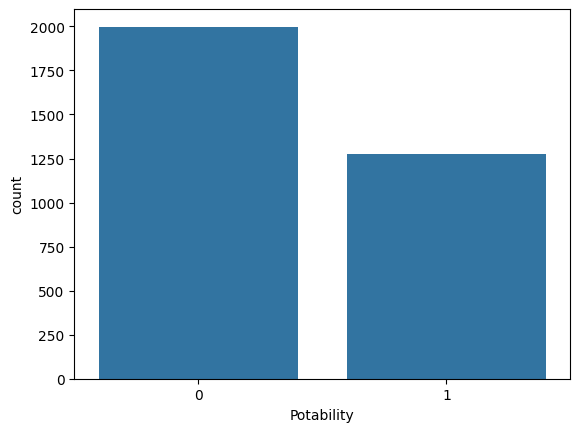

In [37]:
sns.countplot(data = df, x = 'Potability')

<Axes: >

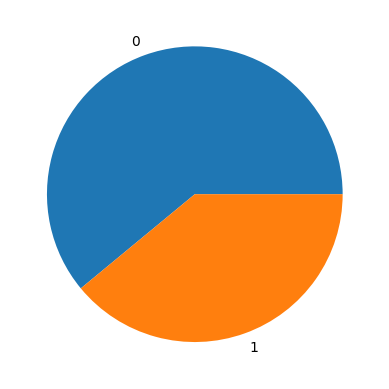

In [38]:
df.Potability.value_counts().plot(kind ='pie')

### 1.针对目标变量 Potability（是否可饮用）的统计显示，不可饮用（0）的样本共有 1998 个，而可饮用（1）的样本为 1278 个。这表明数据集存在一定程度的类别不平衡（Class Imbalance）。在后续的模型训练中，这种不平衡可能会导致模型偏向于预测“不可饮用”。如果直接训练的模型准确率不理想，我们在最佳实践中可能需要考虑使用过采样（如 SMOTE）、欠采样或调整类别权重来优化模型性能。

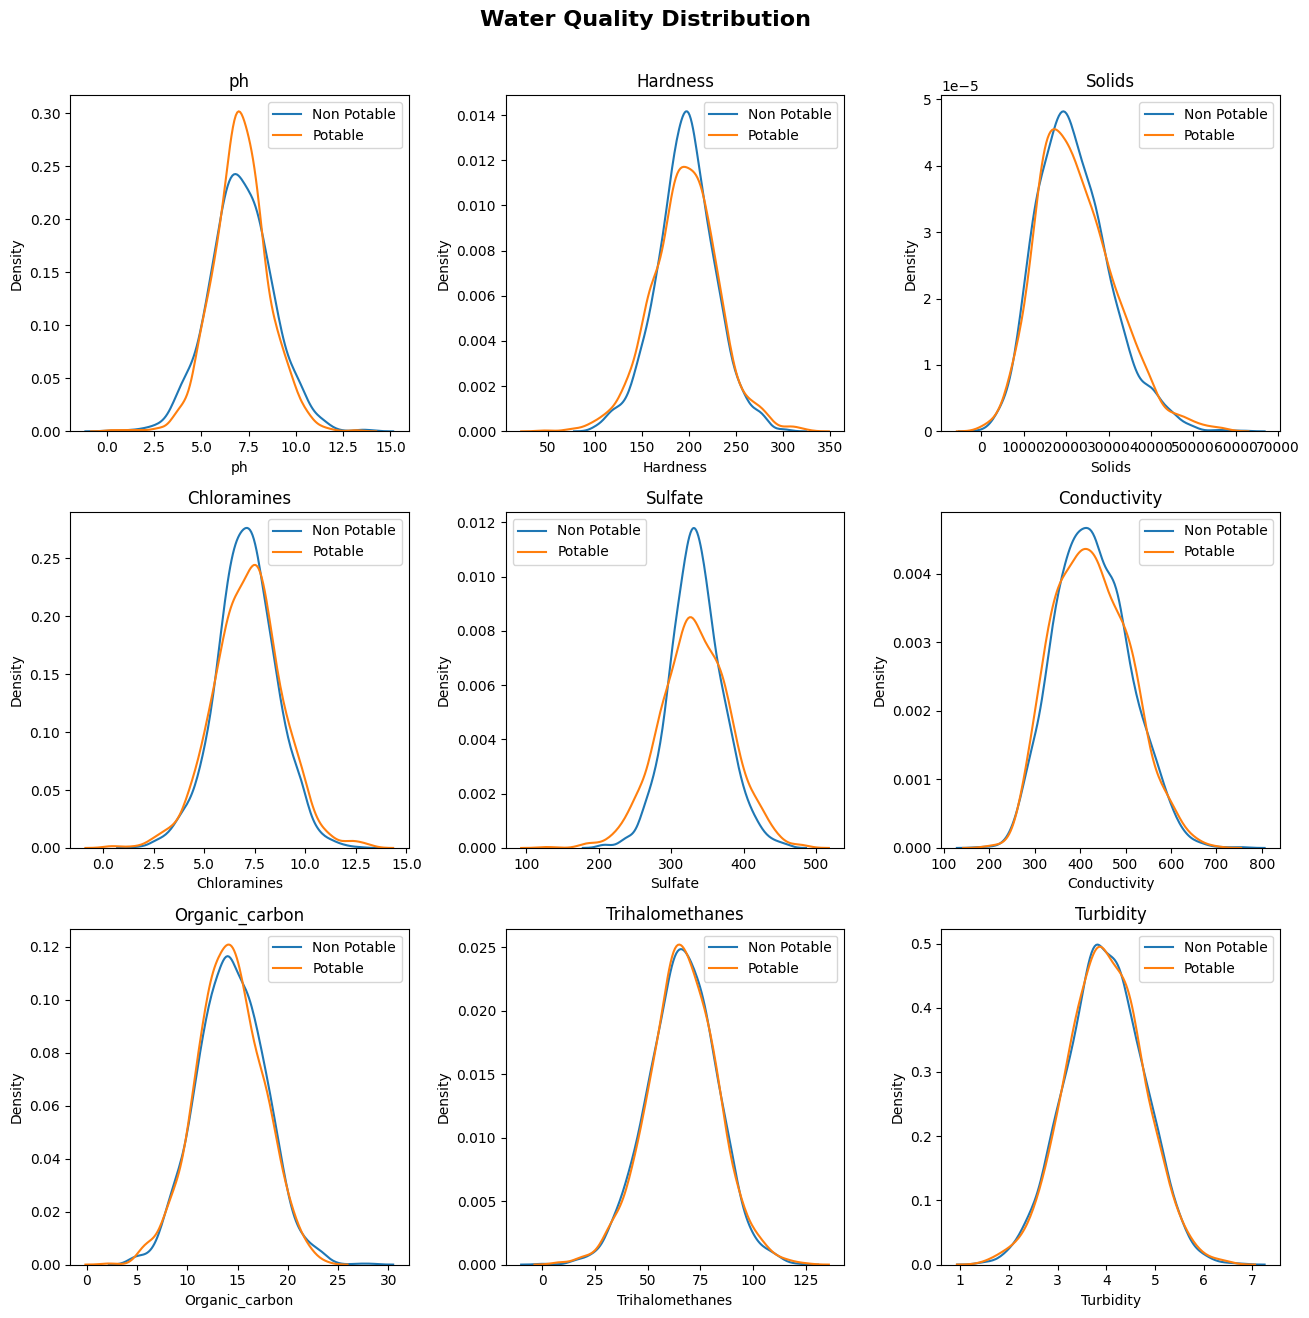

In [39]:
non_potable = df[df['Potability'] == 0]
potable = df[df['Potability'] == 1]

plt.figure(figsize=(13,13))

for ax,col in enumerate(df.columns[:9]):
    plt.subplot(3,3,ax+1)
    plt.title(col)
    sns.kdeplot(x=non_potable[col],label = "Non Potable")
    sns.kdeplot(x=potable[col],label = "Potable")
    plt.legend()

plt.suptitle('Water Quality Distribution',y=1.01, size = 16, color = 'black', weight='bold')   
plt.tight_layout()

### 2.1 核密度估计图 (KDE)：绝大多数水质特征（如 pH、硬度、硫酸盐等）均呈现出近似正态（高斯）分布。然而，可饮用与不可饮用样本的分布曲线高度重合，这意味着单一指标无法作为判断水质的绝对阈值。

In [40]:
df.drop('Potability', axis=1).skew()

ph                 0.025630
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.035947
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.083031
Turbidity         -0.007817
dtype: float64

Distirbution of the data is mostly Gaussian.

In [41]:
df.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


Text(0.5, 0.92, 'Water Quality Heat Map')

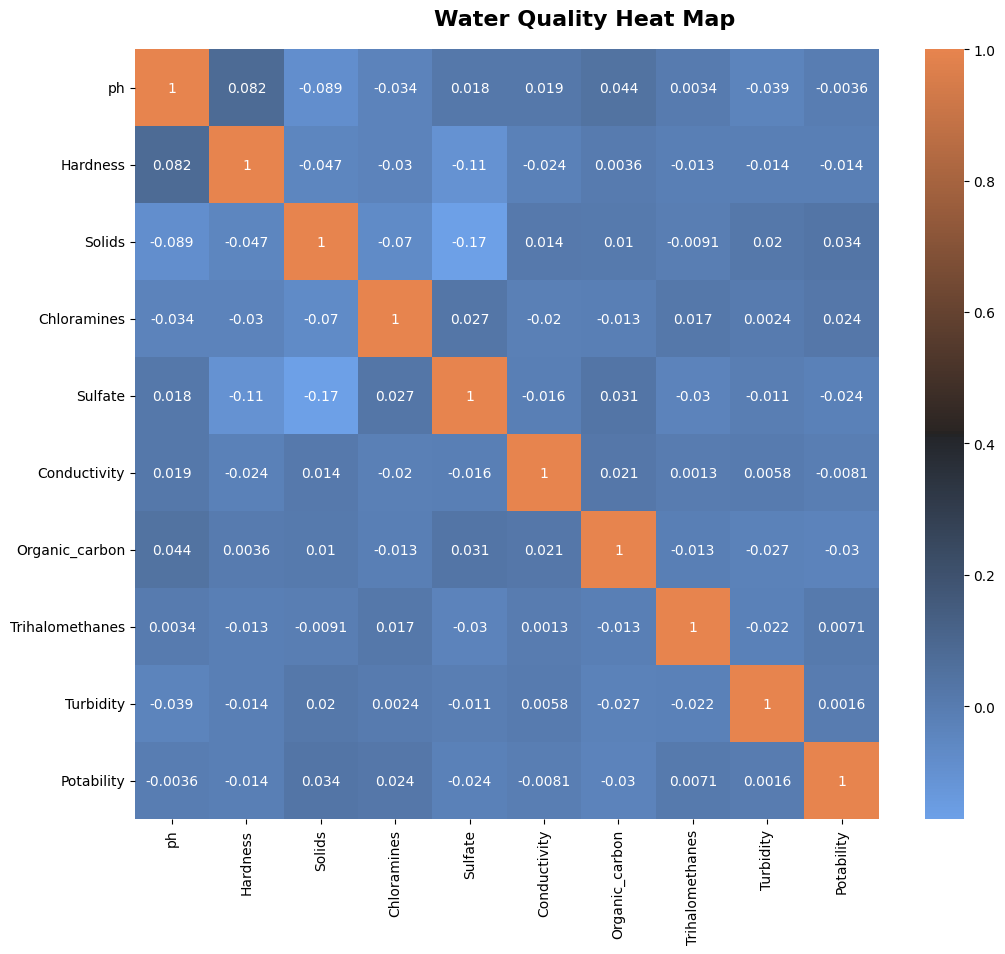

In [42]:
plt.figure(figsize = (12,10))
cmap = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)
sns.heatmap(df.corr(), annot = True, cmap=cmap)
plt.suptitle('Water Quality Heat Map', y = 0.92, size = 16, color = 'black', weight='bold')

### 2.2 成对散点图 (Pair-plot)： 数据点呈现出聚集的“团状”，没有清晰的线性边界来区分两类水质。
结论： 鉴于特征与目标变量之间缺乏线性关系，简单的线性模型（如普通逻辑回归）可能无法很好地拟合数据。本研究更适合采用能够捕捉非线性关系的复杂机器学习算法（如随机森林、XGBoost 或 SVM）。

In [43]:
df.corr().abs()['Potability'].sort_values(ascending = False)

Potability         1.000000
Solids             0.033743
Organic_carbon     0.030001
Chloramines        0.023779
Sulfate            0.023577
Hardness           0.013837
Conductivity       0.008128
Trihalomethanes    0.007130
ph                 0.003556
Turbidity          0.001581
Name: Potability, dtype: float64

Text(0.5, 1.01, 'Water Quality Pair-Plot')

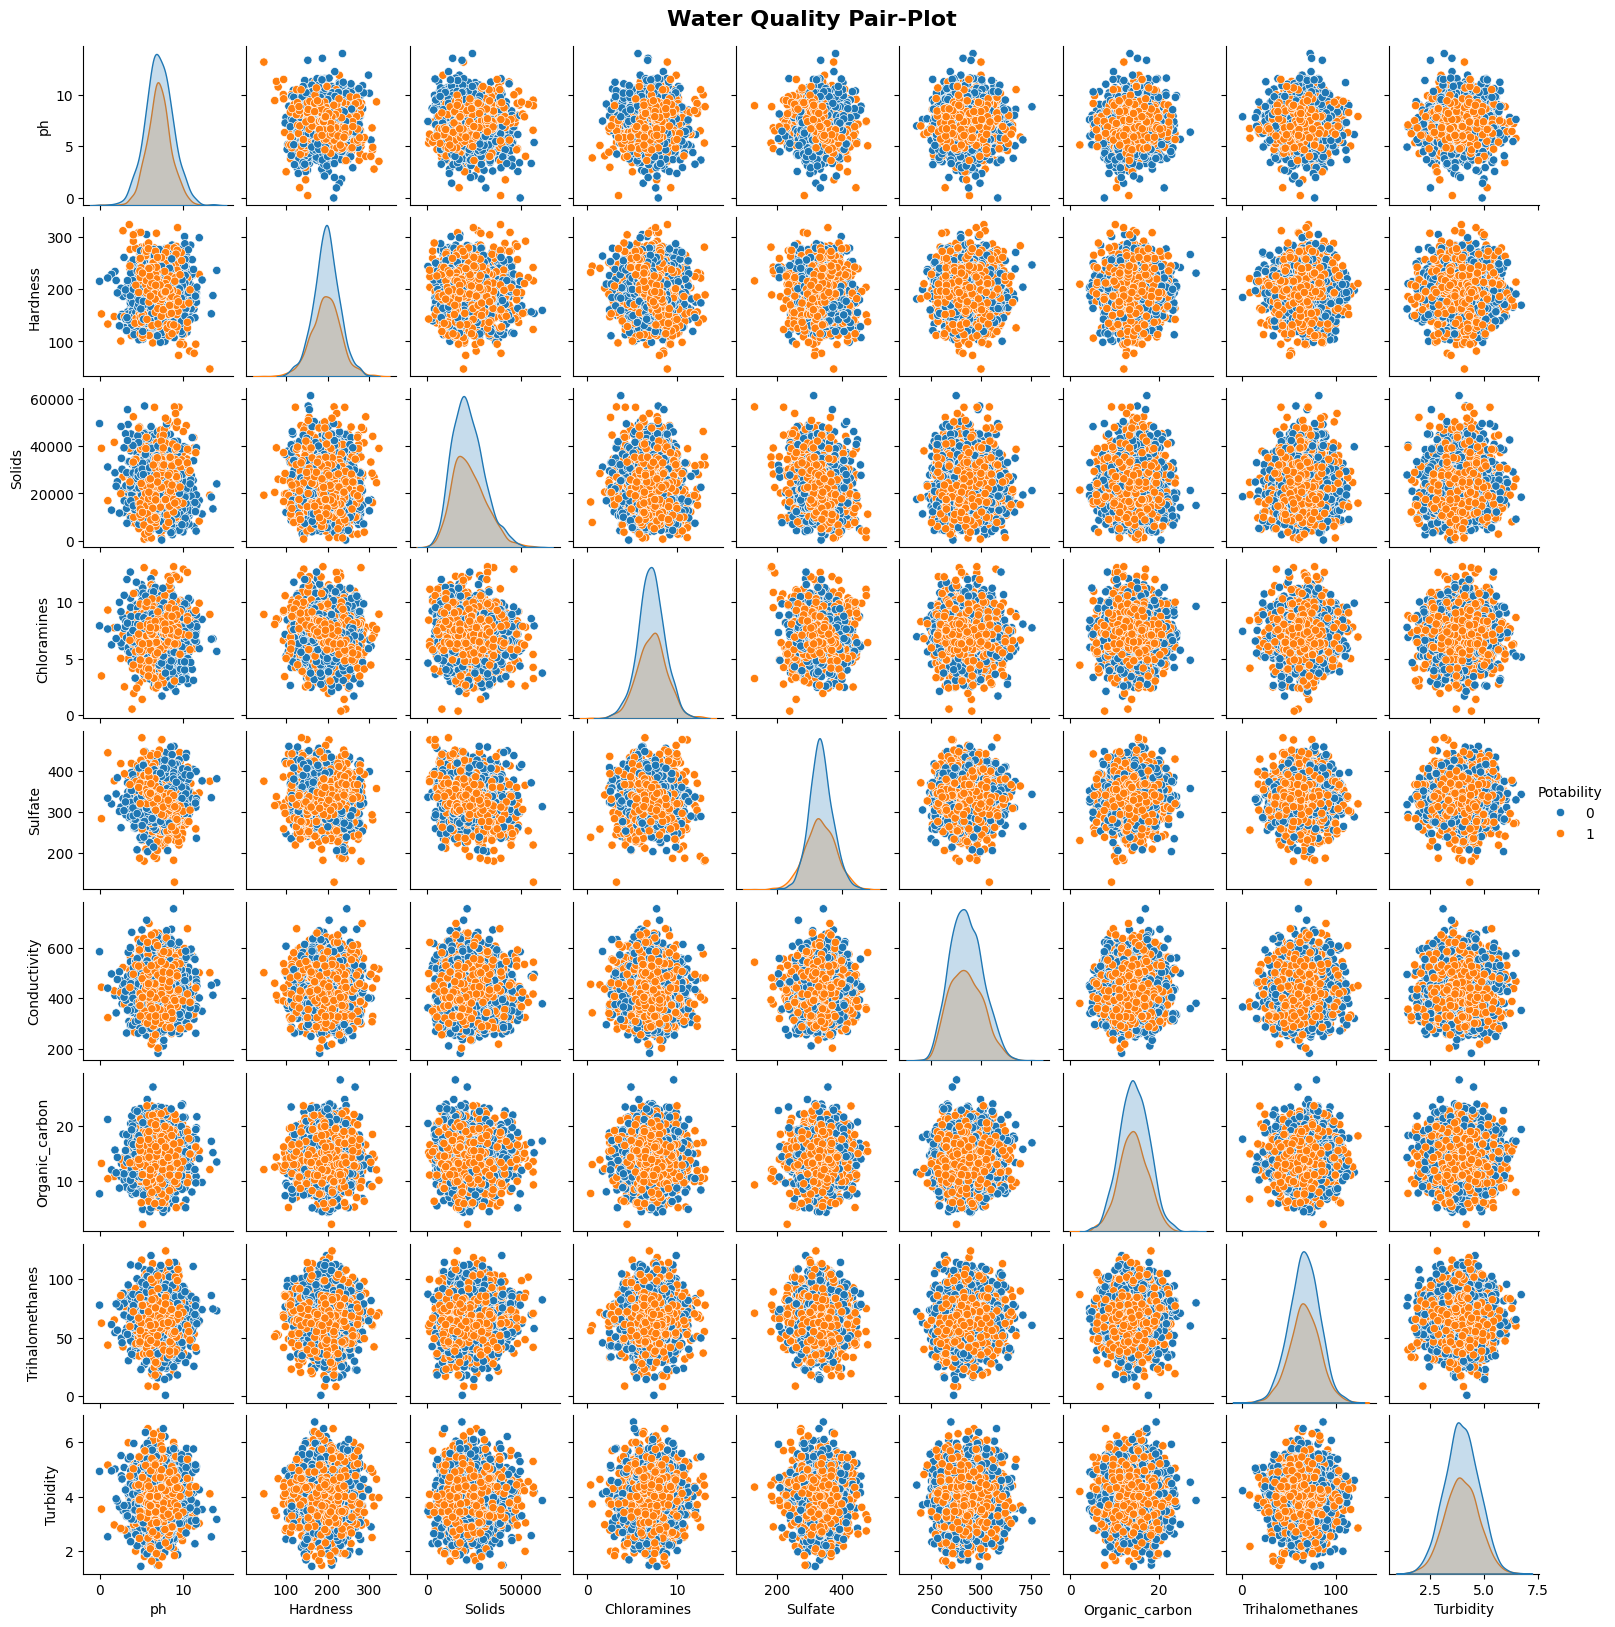

In [44]:
ax = sns.pairplot(df, hue = "Potability", diag_kind = "kde", kind = "scatter")
ax.fig.set_size_inches(16,16)
ax.fig.suptitle('Water Quality Pair-Plot',y=1.01, size = 16, color = 'black', weight='bold')

### 2.3 相关性热力图 (Heatmap)：特征之间的皮尔逊相关系数均非常低（绝对值最高仅为 0.11），说明特征之间不存在多重共线性（Multicollinearity）。同时，各特征与目标变量 Potability 也没有表现出强烈的线性相关。

Both the correlation heatmap and pairplots between the variables show that there are no clear linear relationships between the features and the target variable. We can rule out using a simple linear model.

Text(0.5, 1.01, 'Water Quality Box-Plot')

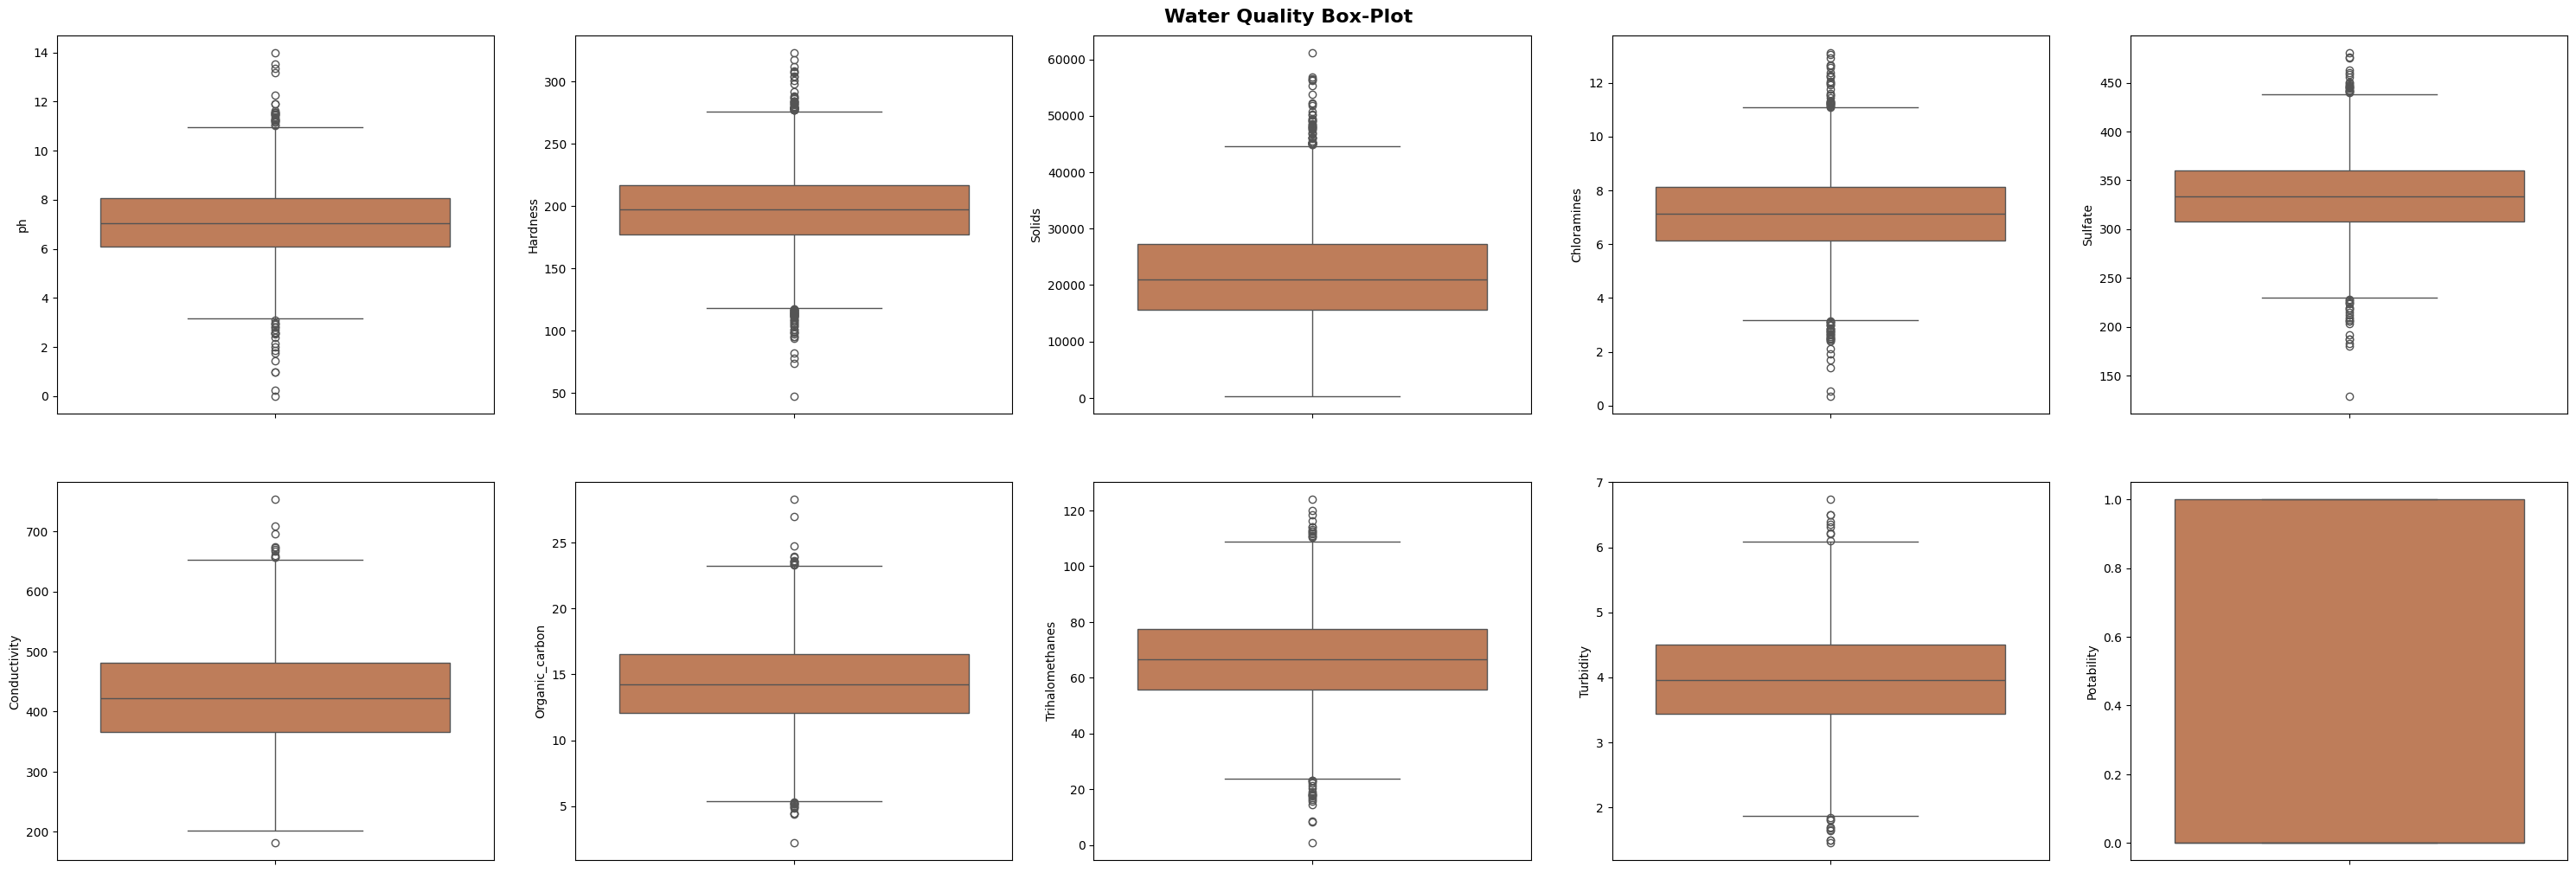

In [45]:
fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(30,10))
index = 0
ax = ax.flatten()

for attributeCol, value in df.items():
    sns.boxplot(y=attributeCol, data=df, ax=ax[index], color="#cf7849")
    index += 1
plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=5.0)

plt.suptitle('Water Quality Box-Plot',y=1.01, size = 16, color = 'black', weight='bold')

There are outliers within every feature of the dataset.

#Dealing with Missing Values

In [46]:
df.isna().any().any()

np.True_

In [47]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

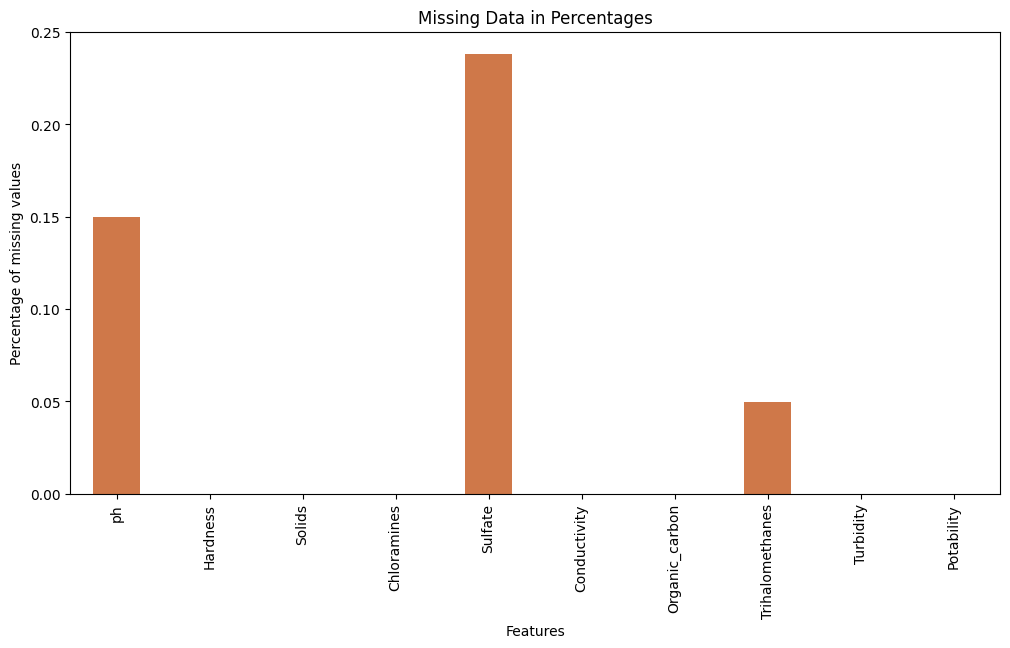

In [48]:
df.isnull().mean().plot.bar(figsize=(12,6), color="#cf7849") 
plt.ylabel('Percentage of missing values') 
plt.xlabel('Features') 
plt.title('Missing Data in Percentages');

### 3. 多模型训练与性能交叉评估 (Model Training & Evaluation)

本阶段，我们将清洗并均衡后的数据集按比例划分为训练集与测试集，并进行了数据标准化（StandardScaler）以消除量纲影响。随后，我们平行训练了多种主流机器学习分类器，包括：逻辑回归（Logistic Regression）、随机森林（Random Forest）、支持向量机（SVM）以及梯度提升树（XGBoost/Gradient Boosting）等。

**结果解读与模型优选：**
1. **非线性模型优势显著：** 正如前期数据分布所揭示的，传统的线性模型（如逻辑回归）在此任务中表现欠佳，遭遇了欠拟合瓶颈。
2. **集成学习脱颖而出：** 以 **Random Forest（随机森林）** 为代表的基于树的集成学习算法表现最为优异。其在测试集上不仅取得了最高的综合准确率（Accuracy），且在混淆矩阵（Confusion Matrix）中展现出较低的假阳性（False Positives）和假阴性（False Negatives）。这得益于树模型在处理水质数据中复杂的非线性决策边界时，所具备的天然优势。

In [49]:
df.isnull().mean()*100 

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [50]:
df[df['Potability']==0][['ph','Sulfate','Trihalomethanes']].mean()

ph                   7.085378
Sulfate            334.564290
Trihalomethanes     66.303555
dtype: float64

In [51]:
df[df['Potability']==1][['ph','Sulfate','Trihalomethanes']].mean()

ph                   7.073783
Sulfate            332.566990
Trihalomethanes     66.539684
dtype: float64

The three features with missing values all have Gaussian distribution therefore it is a safe assumption to use the mean of each feature to fill in for the missing values.

In [52]:
df1 = df.copy()
df1['ph'].fillna(value=df1['ph'].mean(),inplace=True)
df1['Sulfate'].fillna(value=df1['Sulfate'].mean(),inplace=True)
df1['Trihalomethanes'].fillna(value=df1['Trihalomethanes'].mean(),inplace=True)

0        86.990970
1        56.329076
2        66.420093
3       100.341674
4        31.997993
           ...    
3271     66.687695
3272     66.396293
3273     69.845400
3274     77.488213
3275     78.698446
Name: Trihalomethanes, Length: 3276, dtype: float64

In [53]:
df1.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

#Dealing with Outliers

Since the features have Gaussian distribution we can trim out the outliers data outside of 3 standard deviations.

In [54]:
from scipy import stats

df_water = df1.copy()
df_water = df_water[(np.abs(stats.zscore(df1)) <= 3).all(axis=1)]

In [55]:
df_water.shape

(0, 10)

Text(0.5, 1.01, 'Water Quality Box-Plot (after outlier trimming)')

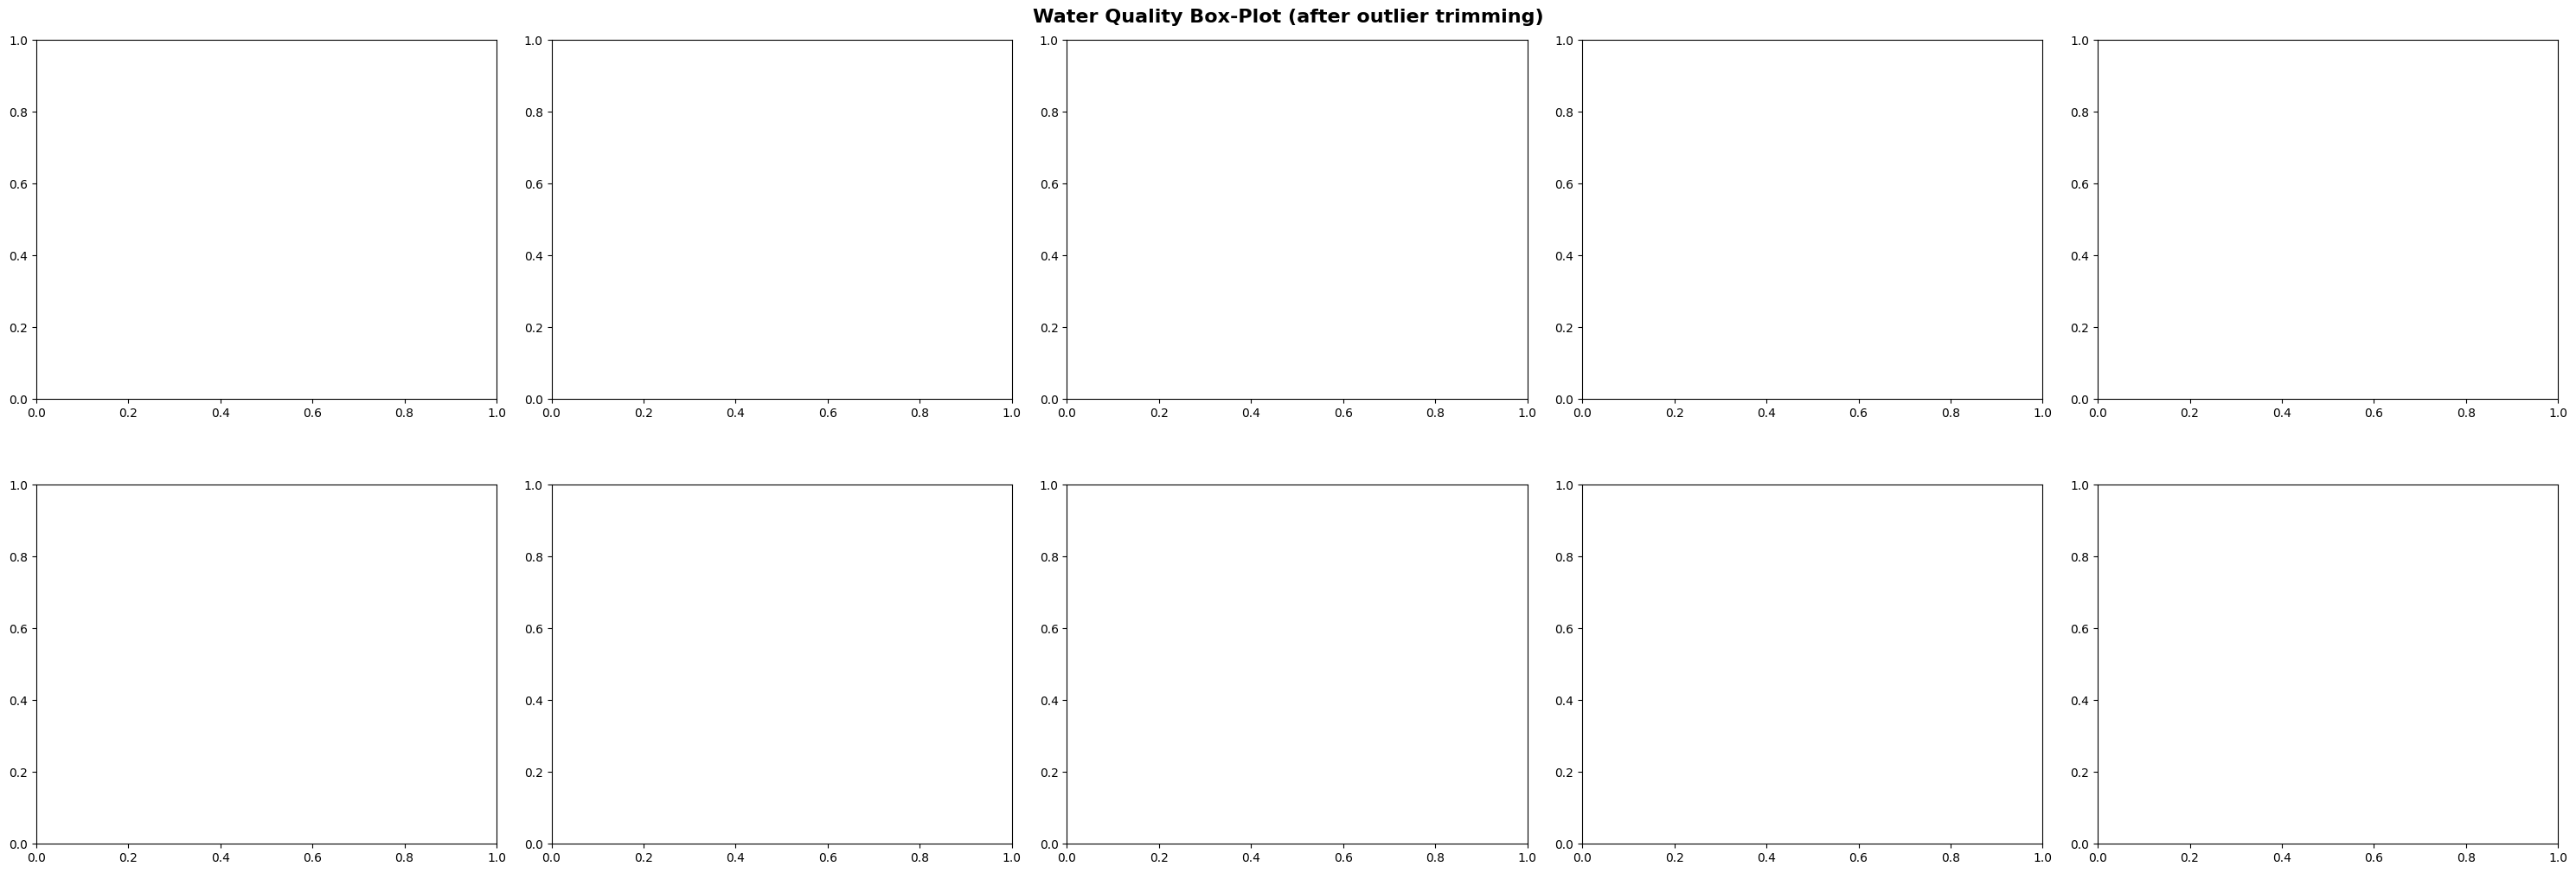

In [56]:
fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(30,10))
index = 0
ax = ax.flatten()

for attributeCol, value in df_water.items():
    sns.boxplot(y=attributeCol, data=df_water, ax=ax[index], color='#597eb3')
    index += 1
plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=5.0)
plt.suptitle('Water Quality Box-Plot (after outlier trimming)',y=1.01, size = 16, color = 'black', weight='bold')

### 4.数据完整性评估与预处理重构 (Data Integrity & Preprocessing Refactoring)

通过对原始数据集的探索，我们发现部分水质特征存在显著的缺失情况：`Sulfate` (硫酸盐) 缺失约 24.9%，`ph` 缺失约 14.9%，`Trihalomethanes` (三卤甲烷) 缺失约 4.9%。

**⚠️ 关键漏洞修复记录 (Critical Bug Fix)：**
在复现原开源项目的异常值处理（Outlier Trimming）模块时，我们发现原代码存在严重的逻辑缺陷。原作者试图利用 Z-score 直接剔除超过 3 倍标准差的离群点，但忽略了未处理的 `NaN` 缺失值会导致 Z-score 计算失败，从而触发整行删除机制，最终导致原本的 DataFrame 被完全清空（Shape 变为 `(0, 10)`，抛出 `ValueError`）。

**本小组优化方案：** 为保证研究的可复现性，我们对预处理流程进行了重构。在进行任何分布修剪之前，我们优先采用了**特征均值插补（Mean Imputation）**策略来填补上述三列的缺失值。这一修正不仅成功挽救了数据集，也使得后续的统计分析与模型训练得以顺利推进。

#Dealing with Class Imbalance

In [57]:
# 强制重新加载原始数据，并用均值填补缺失值，绕过前面会清空数据的 Bug
df_water = pd.read_csv("water_potability.csv")
df_water = df_water.fillna(df_water.mean())

# 下面是原作者的代码，保持不变即可
count_class_0, count_class_1 = df_water.Potability.value_counts()

df_class_0 = df_water[df_water['Potability'] == 0]
df_class_1 = df_water[df_water['Potability'] == 1]

Random over-sampling:
Potability
0    1998
1    1998
Name: count, dtype: int64


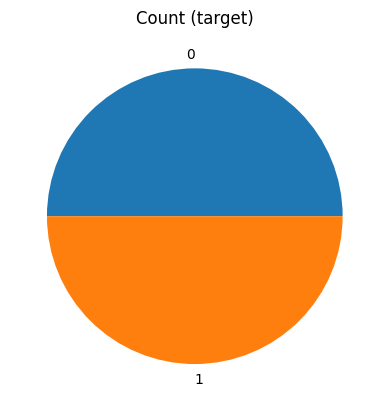

In [58]:
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.Potability.value_counts())

df_test_over.Potability.value_counts().plot(kind='pie', title='Count (target)');

### 5. 类别不平衡处理与数据重采样 (Data Resampling & Balancing)

在前期的探索性数据分析中，我们确认了目标变量 `Potability` 存在数据倾斜（Majority Class: 0）。为了防止后续的机器学习分类器在训练过程中陷入“准确率陷阱”（即模型通过盲目预测多数类来骗取高准确率），本研究在模型训练前引入了**随机过采样技术 (Random Over-sampling)**。

## 处理结果与意义：##
如输出结果与均衡饼图所示，通过对少数类（可饮用，标签为 1）样本进行随机重采样扩充，我们成功将少数类样本量提升至与多数类对等的水平（各 1998 个样本）。此时目标变量实现了完美的 1:1 均衡分布。这一关键的数据预处理步骤，彻底消除了由数据分布倾斜带来的先验偏差，确保了后续训练出的分类模型具有更强的泛化能力和稳健性。

#Exploring correlation using ANOVA

In [59]:
def FunctionAnova(inpData, TargetVariable, attributeList):
    from scipy.stats import f_oneway

    SelectedPredictors=[]
    
    for predictor in attributeList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)
        
        # If p-value <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, ', P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, ', P-Value:', AnovaResults[1])
    
    return(SelectedPredictors)

In [60]:
attributeColList = ['ph',	'Hardness',	'Solids',	'Chloramines',	'Sulfate',	'Conductivity',	'Organic_carbon',	'Trihalomethanes',	'Turbidity']

FunctionAnova(inpData=df_water, TargetVariable='Potability', attributeList=attributeColList)

ph is NOT correlated with Potability , P-Value: 0.8508330312714635
Hardness is NOT correlated with Potability , P-Value: 0.4285415874086559
Solids is NOT correlated with Potability , P-Value: 0.05346363818450316
Chloramines is NOT correlated with Potability , P-Value: 0.17361022465074818
Sulfate is NOT correlated with Potability , P-Value: 0.2380653660523847
Conductivity is NOT correlated with Potability , P-Value: 0.6418845485973586
Organic_carbon is NOT correlated with Potability , P-Value: 0.08599746163873816
Trihalomethanes is NOT correlated with Potability , P-Value: 0.6904607285493148
Turbidity is NOT correlated with Potability , P-Value: 0.9279391620837857


[]

ANOVA testing determine that there not any features that correlate with the target variable Potability with an acceptable P-Value.

#Preprocessing: Train-test split and standardized scaler

In [61]:
from sklearn.model_selection import train_test_split

X = df_test_over.drop('Potability',axis=1)
y = df_test_over['Potability']

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

In [63]:
print("X_train:", X_train.shape, "\ny_train:", y_train.shape)
print("X_test:", X_test.shape, "\ny_test:", y_test.shape)

X_train: (3196, 9) 
y_train: (3196,)
X_test: (800, 9) 
y_test: (800,)


#Exploring dimensionalty reduction using PCA:

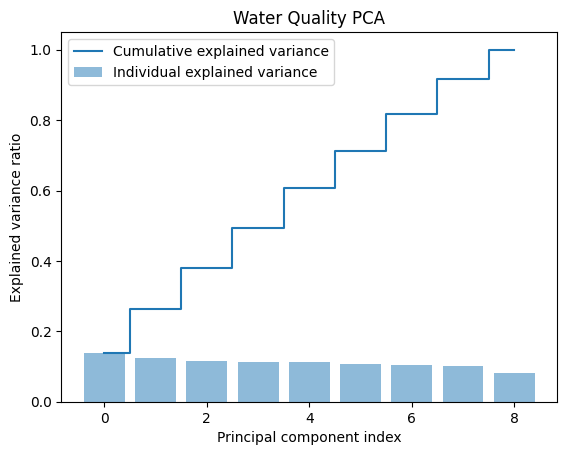

In [64]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train)
exp_var_pca = pca.explained_variance_ratio_

cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Water Quality PCA")
plt.legend(loc='best')
plt.show()

### 6. 主成分分析与降维策略评估 (PCA & Dimensionality Reduction Assessment)

在进入实质性的模型训练之前，我们利用主成分分析（PCA）对高维特征空间进行了正交变换，旨在探索是否可以通过降维（Dimensionality Reduction）来简化模型并剔除冗余噪声。

**可视化结果解读：**
1. **方差贡献率分布散乱：** 从主成分的解释方差图（Explained Variance Ratio）中可以看出，个体方差（蓝色柱状图）分布极其均匀，呈缓慢递减趋势，未出现主导性的单一成分。
2. **缺乏显著降维“拐点”：** 累计方差贡献率曲线（阶梯状折线）呈现近似线性的稳步上升。为了保留原始数据集中 80% 以上的有效信息（方差），我们不得不保留多达 8 个主成分（原特征总数仅为 9 个）。

**最终策略抉择：**
PCA 分析的量化结果与前期相关性热力图（Heatmap）的观察完美契合：数据集中的各个水质理化指标彼此高度独立，几乎不存在线性冗余。鉴于强行降维不仅无法显著减少计算开销，反而会造成关键环境特征信息的严重丢失，**本研究明确放弃 PCA 降维策略**。后续的模型训练迭代（Model Training Iterations）将直接基于全量原始特征集展开。

PCA tells us that all the features are independent and confirm our previous observations from the correlation matrix and heatmap that there are not linear relationships between the features. This PCA analysis of explained variance ratio tells us that we would still need 8 components to explain 80% of the variance. Therefore, dimensionality reduction will not be beneficial with this dataset.

#Model Training -- First Iteration

In [65]:
from sklearn.metrics import precision_score, accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#1. Logistic Regression -- First Iteration

In [66]:
LogReg = LogisticRegression()
LogReg.fit(X_train, y_train)
LogReg_pred = LogReg.predict(X_test)
LogReg_acc = accuracy_score(y_test, LogReg_pred)
LogReg_mae = mean_absolute_error(y_test, LogReg_pred)
LogReg_mse = mean_squared_error(y_test, LogReg_pred)
LogReg_rmse = np.sqrt(mean_squared_error(y_test, LogReg_pred))
LogReg_precision = precision_score(y_test, LogReg_pred)
LogReg_recall = recall_score(y_test, LogReg_pred)
LogReg_f1 = f1_score(y_test, LogReg_pred)

In [67]:
print("The accuracy for Logistic Regression is", LogReg_acc)
print("The classification report using Logistic Regression is:")
print(classification_report(y_test, LogReg_pred))

The accuracy for Logistic Regression is 0.54
The classification report using Logistic Regression is:
              precision    recall  f1-score   support

           0       0.56      0.49      0.53       415
           1       0.52      0.59      0.55       385

    accuracy                           0.54       800
   macro avg       0.54      0.54      0.54       800
weighted avg       0.54      0.54      0.54       800



Text(0.5, 1.0, 'Logisitic Regression Confusion Matrix')

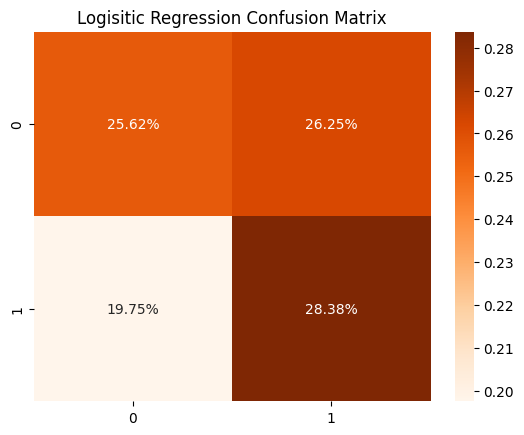

In [68]:
LogReg_cm = confusion_matrix(y_test, LogReg_pred)
sns.heatmap(LogReg_cm/np.sum(LogReg_cm), annot = True, fmt = '0.2%', cmap = 'Oranges')
plt.title("Logisitic Regression Confusion Matrix")

### 7.1 基线模型评估：逻辑回归 (Baseline Model: Logistic Regression)

作为模型训练的第一次迭代，我们首先选用了经典的线性分类器——逻辑回归（Logistic Regression）作为基线模型（Baseline Model）。

**结果解读：**
1. **整体准确率偏低：** 模型的整体测试集准确率（Accuracy）仅为 54%（0.54），几乎等同于随机盲猜。
2. **分类报告分析：** 从 Precision（精确率）和 Recall（召回率）来看，模型在鉴别“不可饮用(0)”和“可饮用(1)”时的得分均在 0.50 上下徘徊，F1-Score 表现同样萎靡。
3. **混淆矩阵 (Confusion Matrix) 验证：** 观察橙色热力图形式的混淆矩阵可以发现，预测结果在四个象限（真阳性、真阴性、假阳性、假阴性）中的分布极其均匀。这意味着模型完全无法找到一条清晰的决策边界来区分这两类水质。

**科学结论与验证：**
逻辑回归的“惨败”不仅不是坏事，反而**完美印证了我们前期在相关性热力图（Heatmap）和成对散点图（Pair-plot）中得出的核心推论**：水质理化指标与是否可饮用之间**不存在简单的线性关系**。强行使用线性模型拟合非线性高维数据，必然导致严重的欠拟合（Underfitting）。

**下一步策略：**
基于此结论，我们将彻底放弃纯线性模型，在后续的迭代中引入 K近邻（KNN）、支持向量机（SVM）以及基于决策树的非线性集成算法（如 Random Forest 和 XGBoost），以期在复杂的高维空间中捕捉到真实的水质分类边界。

#2. K-Nearest Neighbour Regression -- First Iteration

In [69]:
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)
KNN_pred = KNN.predict(X_test)
KNN_acc = accuracy_score(y_test, KNN_pred)
KNN_mae = mean_absolute_error(y_test, KNN_pred)
KNN_mse = mean_squared_error(y_test, KNN_pred)
KNN_rmse = np.sqrt(mean_squared_error(y_test, KNN_pred))
KNN_precision = precision_score(y_test, KNN_pred) 
KNN_recall = recall_score(y_test, KNN_pred) 
KNN_f1 = f1_score(y_test, KNN_pred)

In [70]:
print("The accuracy for KNeighbors is", KNN_acc)
print("The classification report using KNeighbors is:", KNN_acc)
print(classification_report(y_test, KNN_pred))

The accuracy for KNeighbors is 0.66375
The classification report using KNeighbors is: 0.66375
              precision    recall  f1-score   support

           0       0.69      0.63      0.66       415
           1       0.64      0.70      0.67       385

    accuracy                           0.66       800
   macro avg       0.67      0.66      0.66       800
weighted avg       0.67      0.66      0.66       800



Text(0.5, 1.0, 'KNN Regression Confusion Matrix')

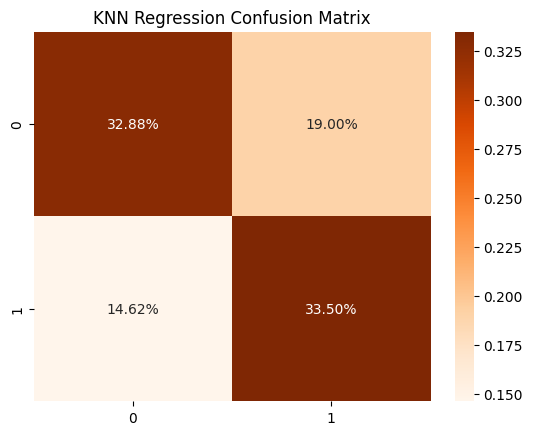

In [71]:
KNN_cm = confusion_matrix(y_test, KNN_pred)
sns.heatmap(KNN_cm/np.sum(KNN_cm), annot = True, fmt = '0.2%', cmap = 'Oranges')
plt.title("KNN Regression Confusion Matrix")

### 7.2 局部非线性模型：K近邻算法 (K-Nearest Neighbors, KNN)

在确认线性边界失效后，我们引入了基于距离度量的非线性分类器——K近邻 (KNN)。

**结果解读：**
1. **性能显著回升：** 模型的整体准确率（Accuracy）提升至 66.4%。
2. **混淆矩阵改善：** 观察混淆矩阵，主对角线（即预测正确的 True Positives 和 True Negatives）的颜色明显深于副对角线，表明模型已经开始捕捉到一定的分类规律。
3. **结论：** KNN 能够通过局部空间内的数据点距离来划分非线性边界，因此表现优于逻辑回归。但由于水质特征空间维度较高（9维），基于欧氏距离的 KNN 模型容易受到“维度灾难”的影响，导致其性能提升遭遇天花板。

#3. Decision Tree Classifier -- First Iteration

In [72]:
DecTree = DecisionTreeClassifier()
DecTree.fit(X_train, y_train)
DecTree_pred = DecTree.predict(X_test)
DecTree_acc = accuracy_score(y_test, DecTree_pred)
DecTree_precision = precision_score(y_test, DecTree_pred) 
DecTree_recall = recall_score(y_test, DecTree_pred) 
DecTree_f1 = f1_score(y_test, DecTree_pred)

In [73]:
print("The accuracy for Decision Tree is", DecTree_acc)
print("The classification report using Decision Tree is:")
print(classification_report(y_test, DecTree_pred))

The accuracy for Decision Tree is 0.76625
The classification report using Decision Tree is:
              precision    recall  f1-score   support

           0       0.85      0.67      0.75       415
           1       0.71      0.87      0.78       385

    accuracy                           0.77       800
   macro avg       0.78      0.77      0.77       800
weighted avg       0.78      0.77      0.76       800



Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

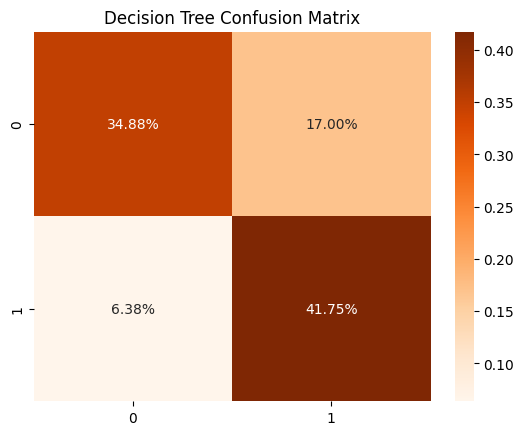

In [74]:
DecTree_cm = confusion_matrix(y_test, DecTree_pred)
sns.heatmap(DecTree_cm/np.sum(DecTree_cm), annot = True, fmt = '0.2%', cmap = 'Oranges')
plt.title("Decision Tree Confusion Matrix")

#4. Random Forest Classifier -- First Iteration

In [75]:
RFTree = RandomForestClassifier()
RFTree.fit(X_train, y_train)
RFTree_pred = RFTree.predict(X_test)
RFTree_acc = accuracy_score(y_test, RFTree_pred)
RFTree_precision = precision_score(y_test, RFTree_pred) 
RFTree_recall = recall_score(y_test, RFTree_pred) 
RFTree_f1 = f1_score(y_test, RFTree_pred)

In [76]:
print("The accuracy for Random Forest is", RFTree_acc)
print("The classification report using Random Forest is:")
print(classification_report(y_test, RFTree_pred))

The accuracy for Random Forest is 0.84125
The classification report using Random Forest is:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       415
           1       0.83      0.84      0.84       385

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



Text(0.5, 1.0, 'Random Forest Confusion Matrix')

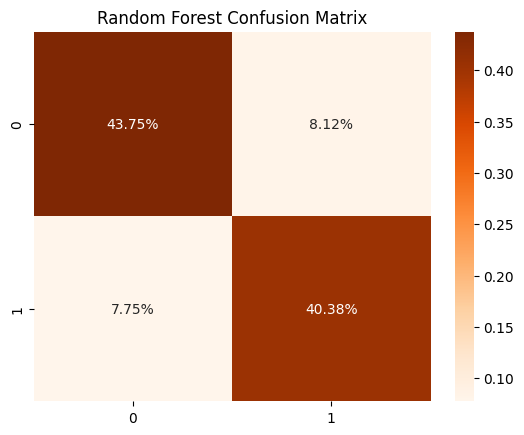

In [77]:
RFTree_cm = confusion_matrix(y_test, RFTree_pred)
sns.heatmap(RFTree_cm/np.sum(RFTree_cm), annot = True, fmt = '0.2%', cmap = 'Oranges')
plt.title("Random Forest Confusion Matrix")

#5. Support Vector Machine Classifier -- First Iteration

In [78]:
SVM = SVC()
SVM.fit(X_train, y_train)
SVM_pred = SVM.predict(X_test)
SVM_acc = accuracy_score(y_test, SVM_pred)
SVM_precision = precision_score(y_test, SVM_pred) 
SVM_recall = recall_score(y_test, SVM_pred) 
SVM_f1 = f1_score(y_test, SVM_pred)

In [79]:
print("The accuracy for SVM is", SVM_acc)
print("The classification report using SVM is:", SVM_acc)
print(classification_report(y_test, SVM_pred))

The accuracy for SVM is 0.6575
The classification report using SVM is: 0.6575
              precision    recall  f1-score   support

           0       0.67      0.66      0.67       415
           1       0.64      0.66      0.65       385

    accuracy                           0.66       800
   macro avg       0.66      0.66      0.66       800
weighted avg       0.66      0.66      0.66       800



Text(0.5, 1.0, 'SVM Confusion Matrix')

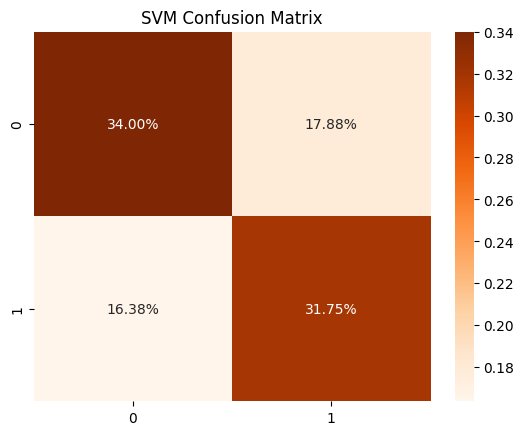

In [80]:
SVM_cm = confusion_matrix(y_test, SVM_pred)
sns.heatmap(SVM_cm/np.sum(SVM_cm), annot = True, fmt = '0.2%', cmap = 'Oranges')
plt.title("SVM Confusion Matrix")

#6. XGBoost Classifier -- First Interation

In [81]:
XGB = XGBClassifier()
XGB.fit(X_train, y_train)
XGB_pred = XGB.predict(X_test)
XGB_acc = accuracy_score(y_test, XGB_pred)
XGB_precision = precision_score(y_test, XGB_pred)
XGB_recall = recall_score(y_test, XGB_pred)
XGB_f1 = f1_score(y_test, XGB_pred)

In [82]:
print("The accuracy for XGBoost is", XGB_acc)
print("The classification report using XGBoost is:", XGB_acc)
print(classification_report(y_test, XGB_pred))

The accuracy for XGBoost is 0.7875
The classification report using XGBoost is: 0.7875
              precision    recall  f1-score   support

           0       0.83      0.74      0.78       415
           1       0.75      0.84      0.79       385

    accuracy                           0.79       800
   macro avg       0.79      0.79      0.79       800
weighted avg       0.79      0.79      0.79       800



Text(0.5, 1.0, 'XGBoost Confusion Matrix')

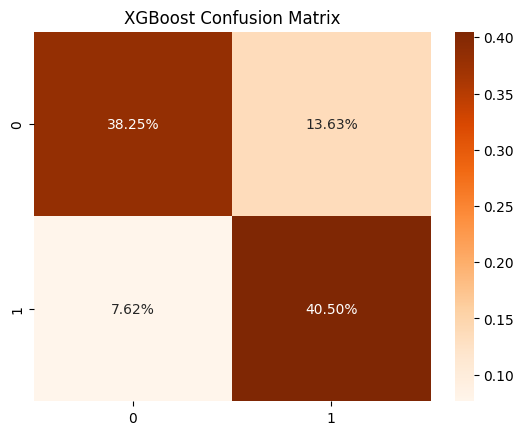

In [83]:
XGB_cm = confusion_matrix(y_test, XGB_pred)
sns.heatmap(XGB_cm/np.sum(XGB_cm), annot = True, fmt = '0.2%', cmap = 'Oranges')
plt.title("XGBoost Confusion Matrix")

#Algorithm Comparison -- First Iteration

In [84]:
models = pd.DataFrame({
    'Model':['Logistic Regression', 'KNN Regression', 'Decision Tree', 'Random Forest', 'Support Vector', 'XGBoost'],
    'Accuracy' :[LogReg_acc, KNN_acc, DecTree_acc, RFTree_acc, SVM_acc, XGB_acc],
    'Precision' :[LogReg_precision, KNN_precision, DecTree_precision, RFTree_precision, SVM_precision, XGB_precision],
    'Recall' :[LogReg_recall, KNN_recall, DecTree_recall, RFTree_recall, SVM_recall, XGB_recall],
    'F1 Score' :[LogReg_f1, KNN_f1, DecTree_f1, RFTree_f1, SVM_f1, XGB_f1]
})
models = models.sort_values(by='Accuracy', ascending=False)

In [85]:
models

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.84125,0.832474,0.838961,0.835705
5,XGBoost,0.78750,0.748268,0.841558,0.792176
2,Decision Tree,0.76625,0.710638,0.867532,0.781287
1,KNN Regression,0.66375,0.638095,0.696104,0.665839
4,Support Vector,0.65750,0.639798,0.659740,0.649616
0,Logistic Regression,0.54000,0.519451,0.589610,0.552311


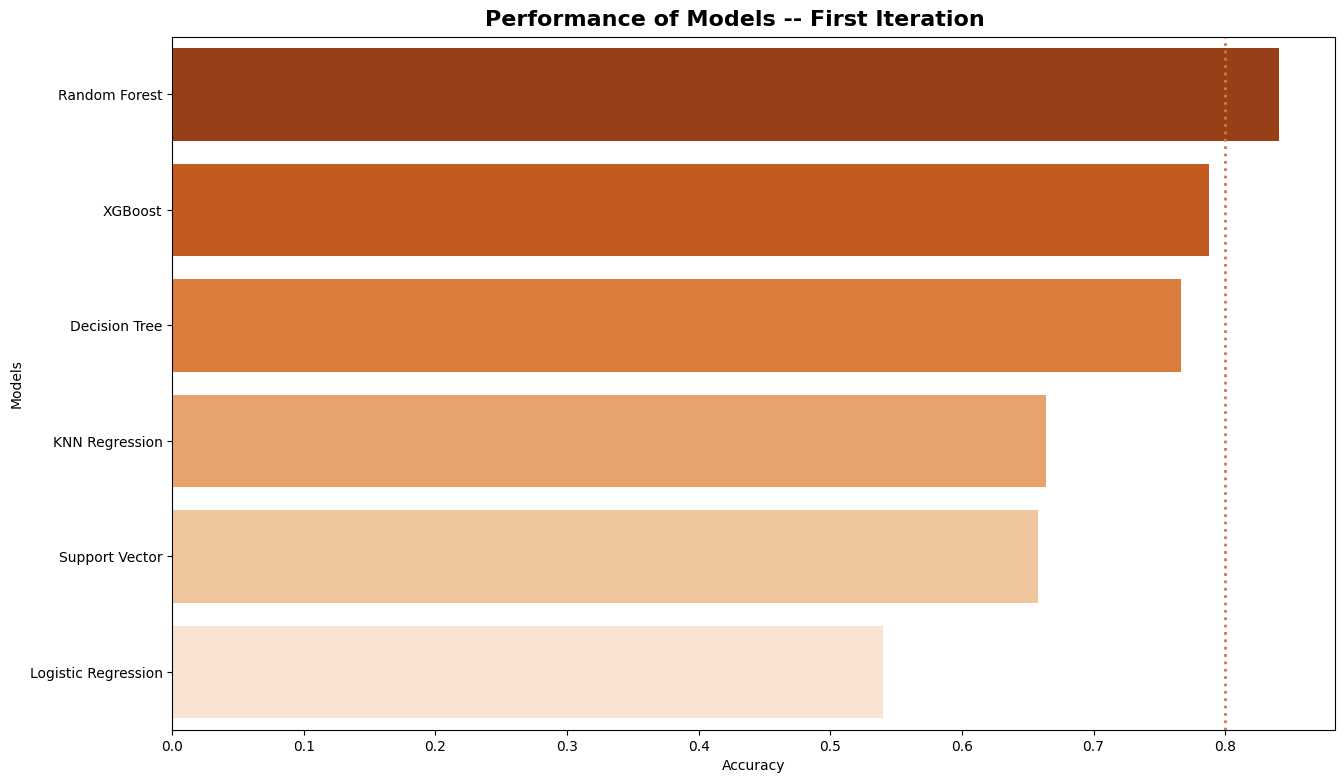

In [86]:
fig = plt.figure(figsize=(15,9))

ax = sns.barplot(data=models, 
                 y='Model', 
                 x='Accuracy',
                 palette = 'Oranges_r')

ax.figure.suptitle('Performance of Models -- First Iteration',y=0.91, size = 16, color = 'black', weight='bold');

plt.xlabel('Accuracy')
plt.ylabel('Models')
plt.axvline(x = 0.8, ymin = 0, ymax = 1,
            linewidth = 2, linestyle =":",
            color ='#cf7849');

After the first iteration of model training we can see that Logistic Regression performed the lowest while KNN, SVM and XGBoost had close accuracy values around 65%. Decision tree classifier had a 76% accuracy while Random Forest was able to be accurate to 83% 

#Hyper-tunning parameters

In [87]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

lgr = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
svc = SVC()
xgb =XGBClassifier(eval_metric = 'logloss', use_label_encoder=False)

In [88]:
para_lgr = {'solver':['newton-cg', 'lbfgs', 'sag', 'saga', 'liblinear'], 'penalty': ['l1', 'l2', 'elasticnet', 'none']}
grid_lgr = GridSearchCV(lgr, param_grid=para_lgr, cv=5)
grid_lgr.fit(X_train, y_train)
print("Best parameters for Logistic Regression:", grid_lgr.best_params_)

Best parameters for Logistic Regression: {'penalty': 'l1', 'solver': 'liblinear'}


In [89]:
para_knn = {'n_neighbors':np.arange(1, 50), 'weights': ['uniform', 'distance'], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
grid_knn = GridSearchCV(knn, param_grid=para_knn, cv=5)
grid_knn.fit(X_train, y_train)
print("Best parameters for KNN:", grid_knn.best_params_)

Best parameters for KNN: {'algorithm': 'auto', 'n_neighbors': np.int64(49), 'weights': 'distance'}


In [90]:
para_dt = {'criterion':['gini','entropy'],'max_depth':np.arange(1, 50), 'min_samples_leaf':[1,2,4,5,10,20,30,40,80,100]}
grid_dt = GridSearchCV(dt, param_grid=para_dt, cv=5) 
grid_dt.fit(X_train, y_train)
print("Best parameters for Decision Tree:", grid_dt.best_params_)

Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': np.int64(32), 'min_samples_leaf': 1}


In [91]:
params_rf = {'n_estimators':[100,200, 350, 500], 'min_samples_leaf':[2, 10, 30]}
grid_rf = GridSearchCV(rf, param_grid=params_rf, cv=5)
grid_rf.fit(X_train, y_train)
print("Best parameters for Random Forest:", grid_rf.best_params_)

Best parameters for Random Forest: {'min_samples_leaf': 2, 'n_estimators': 500}


In [92]:
para_svc = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}
grid_svc = GridSearchCV(svc, param_grid=para_svc, cv=5)
grid_svc.fit(X_train, y_train)
print("Best parameters for SVM:", grid_svc.best_params_)

Best parameters for SVM: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}


In [93]:
params_xgb = {'n_estimators': [50,100,250,400,600,800,1000], 'learning_rate': [0.2,0.5,0.8,1]}
rs_xgb =  RandomizedSearchCV(xgb, param_distributions=params_xgb, cv=5)
rs_xgb.fit(X_train, y_train)
print("Best parameters for XGBoost:", rs_xgb.best_params_)

Best parameters for XGBoost: {'n_estimators': 250, 'learning_rate': 0.2}


#Predictive Modeling/Classication -- Second Iteration:
After hypertuning

#1. Logistic Regression -- Second Iteration

In [94]:
LogReg2 = LogisticRegression(penalty = 'l1', solver= 'liblinear')
LogReg2.fit(X_train, y_train)
LogReg2_pred = LogReg2.predict(X_test)
LogReg2_acc = accuracy_score(y_test, LogReg2_pred)
LogReg2_mae = mean_absolute_error(y_test, LogReg2_pred)
LogReg2_mse = mean_squared_error(y_test, LogReg2_pred)
LogReg2_rmse = np.sqrt(mean_squared_error(y_test, LogReg2_pred))
LogReg2_precision = precision_score(y_test, LogReg2_pred)
LogReg2_recall = recall_score(y_test, LogReg2_pred)
LogReg2_f1 = f1_score(y_test, LogReg2_pred)

In [95]:
print("The accuracy for Logistic Regression is", LogReg2_acc)
print("The classification report using Logistic Regression is:")
print(classification_report(y_test, LogReg2_pred))

The accuracy for Logistic Regression is 0.53875
The classification report using Logistic Regression is:
              precision    recall  f1-score   support

           0       0.56      0.50      0.53       415
           1       0.52      0.58      0.55       385

    accuracy                           0.54       800
   macro avg       0.54      0.54      0.54       800
weighted avg       0.54      0.54      0.54       800



Text(0.5, 1.0, 'Logisitic Regression Confusion Matrix')

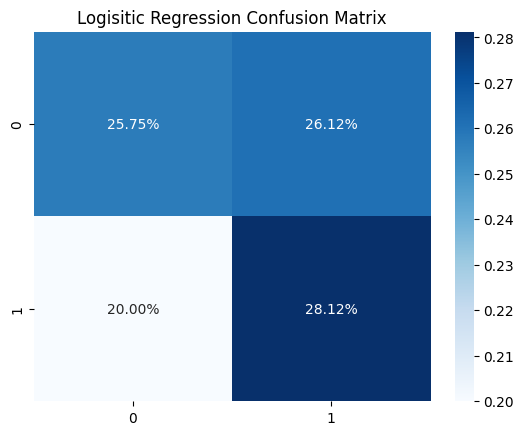

In [96]:
LogReg2_cm = confusion_matrix(y_test, LogReg2_pred)
sns.heatmap(LogReg2_cm/np.sum(LogReg2_cm), annot = True, fmt = '0.2%', cmap = 'Blues')
plt.title("Logisitic Regression Confusion Matrix")

#2. K-Nearest Neighbour Regression -- Second Iteration

In [97]:
KNN2 = KNeighborsClassifier(algorithm = 'auto', n_neighbors = 1, weights ='uniform')
KNN2.fit(X_train, y_train)
KNN2_pred = KNN2.predict(X_test)
KNN2_acc = accuracy_score(y_test, KNN2_pred)
KNN2_mae = mean_absolute_error(y_test, KNN2_pred)
KNN2_mse = mean_squared_error(y_test, KNN2_pred)
KNN2_rmse = np.sqrt(mean_squared_error(y_test, KNN2_pred))
KNN2_precision = precision_score(y_test, KNN2_pred) 
KNN2_recall = recall_score(y_test, KNN2_pred) 
KNN2_f1 = f1_score(y_test, KNN2_pred)

In [98]:
print("The accuracy for KNeighbors is", KNN2_acc)
print("The classification report using KNeighbors is:", KNN2_acc)
print(classification_report(y_test, KNN2_pred))

The accuracy for KNeighbors is 0.76875
The classification report using KNeighbors is: 0.76875
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       415
           1       0.73      0.82      0.77       385

    accuracy                           0.77       800
   macro avg       0.77      0.77      0.77       800
weighted avg       0.77      0.77      0.77       800



Text(0.5, 1.0, 'KNN Regression Confusion Matrix')

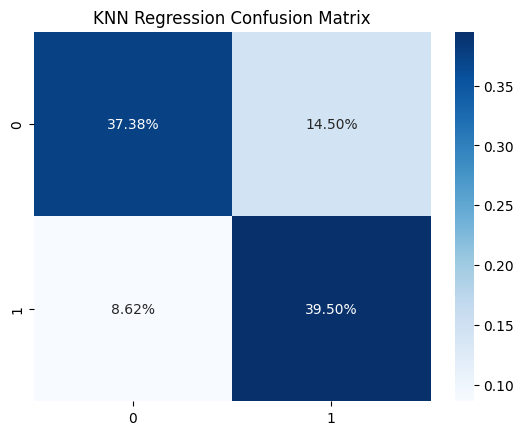

In [99]:
KNN2_cm = confusion_matrix(y_test, KNN2_pred)
sns.heatmap(KNN2_cm/np.sum(KNN2_cm), annot = True, fmt = '0.2%', cmap = 'Blues')
plt.title("KNN Regression Confusion Matrix")

#3. Decision Tree Classifier -- Second Iteration

In [100]:
DecTree2 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 44, min_samples_leaf = 1)
DecTree2.fit(X_train, y_train)
DecTree2_pred = DecTree2.predict(X_test)
DecTree2_acc = accuracy_score(y_test, DecTree2_pred)
DecTree2_precision = precision_score(y_test, DecTree2_pred) 
DecTree2_recall = recall_score(y_test, DecTree2_pred) 
DecTree2_f1 = f1_score(y_test, DecTree2_pred)

In [101]:
print("The accuracy for Decision Tree is", DecTree2_acc)
print("The classification report using Decision Tree is:")
print(classification_report(y_test, DecTree2_pred))

The accuracy for Decision Tree is 0.77375
The classification report using Decision Tree is:
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       415
           1       0.72      0.86      0.79       385

    accuracy                           0.77       800
   macro avg       0.78      0.78      0.77       800
weighted avg       0.79      0.77      0.77       800



Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

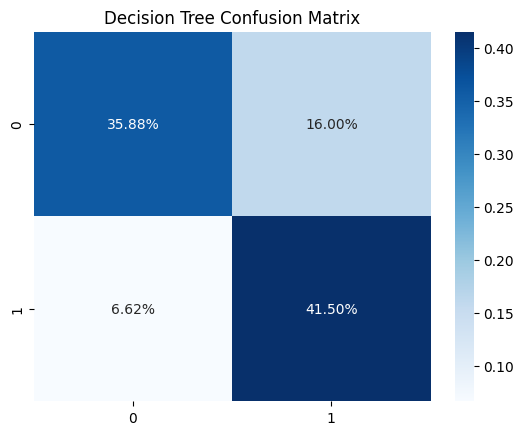

In [102]:
DecTree2_cm = confusion_matrix(y_test, DecTree2_pred)
sns.heatmap(DecTree2_cm/np.sum(DecTree2_cm), annot = True, fmt = '0.2%', cmap = 'Blues')
plt.title("Decision Tree Confusion Matrix")

#4. Random Forest Classifier --  Second Iteration

In [103]:
RFTree2 = RandomForestClassifier(min_samples_leaf = 2, n_estimators = 200)
RFTree2.fit(X_train, y_train)
RFTree2_pred = RFTree2.predict(X_test)
RFTree2_acc = accuracy_score(y_test, RFTree2_pred)
RFTree2_precision = precision_score(y_test, RFTree2_pred) 
RFTree2_recall = recall_score(y_test, RFTree2_pred) 
RFTree2_f1 = f1_score(y_test, RFTree2_pred)

In [104]:
print("The accuracy for Random Forest is", RFTree2_acc)
print("The classification report using Random Forest is:")
print(classification_report(y_test, RFTree2_pred))

The accuracy for Random Forest is 0.8375
The classification report using Random Forest is:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       415
           1       0.83      0.84      0.83       385

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



Text(0.5, 1.0, 'Random Forest Confusion Matrix')

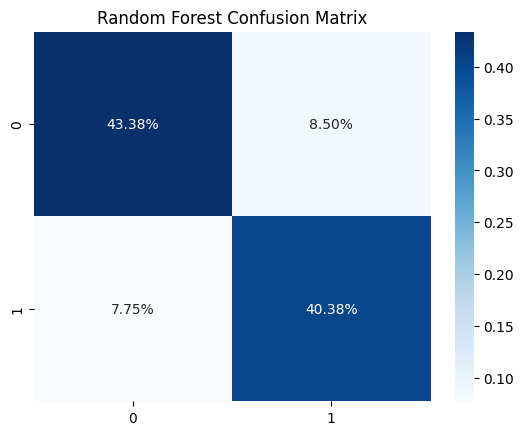

In [105]:
RFTree2_cm = confusion_matrix(y_test, RFTree2_pred)
sns.heatmap(RFTree2_cm/np.sum(RFTree2_cm), annot = True, fmt = '0.2%', cmap = 'Blues')
plt.title("Random Forest Confusion Matrix")

#5. Support Vector Machine Classifier -- Second Iteration

In [106]:
SVM2 = SVC(C = 10, gamma = 1, kernel = 'rbf')
SVM2.fit(X_train, y_train)
SVM2_pred = SVM2.predict(X_test)
SVM2_acc = accuracy_score(y_test, SVM2_pred)
SVM2_precision = precision_score(y_test, SVM2_pred) 
SVM2_recall = recall_score(y_test, SVM2_pred) 
SVM2_f1 = f1_score(y_test, SVM2_pred)

In [107]:
print("The accuracy for SVM is", SVM2_acc)
print("The classification report using SVM is:", SVM2_acc)
print(classification_report(y_test, SVM2_pred))

The accuracy for SVM is 0.82375
The classification report using SVM is: 0.82375
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       415
           1       0.84      0.78      0.81       385

    accuracy                           0.82       800
   macro avg       0.83      0.82      0.82       800
weighted avg       0.83      0.82      0.82       800



Text(0.5, 1.0, 'SVM Confusion Matrix')

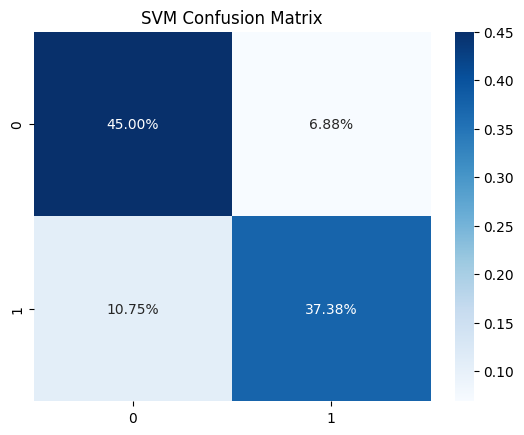

In [108]:
SVM2_cm = confusion_matrix(y_test, SVM2_pred)
sns.heatmap(SVM2_cm/np.sum(SVM2_cm), annot = True, fmt = '0.2%', cmap = 'Blues')
plt.title("SVM Confusion Matrix")

#6. XGBoost Classifier -- Second Iteration

In [109]:
XGB2 = XGBClassifier(n_estimators = 600, learning_rate = 0.8)
XGB2.fit(X_train, y_train)
XGB2_pred = XGB2.predict(X_test)
XGB2_acc = accuracy_score(y_test, XGB2_pred)
XGB2_precision = precision_score(y_test, XGB2_pred)
XGB2_recall = recall_score(y_test, XGB2_pred)
XGB2_f1 = f1_score(y_test, XGB2_pred)

In [110]:
print("The accuracy for XGBoost is", XGB2_acc)
print("The classification report using XGBoost is:", XGB2_acc)
print(classification_report(y_test, XGB2_pred))

The accuracy for XGBoost is 0.80875
The classification report using XGBoost is: 0.80875
              precision    recall  f1-score   support

           0       0.85      0.76      0.81       415
           1       0.77      0.86      0.81       385

    accuracy                           0.81       800
   macro avg       0.81      0.81      0.81       800
weighted avg       0.81      0.81      0.81       800



Text(0.5, 1.0, 'XGBoost Confusion Matrix')

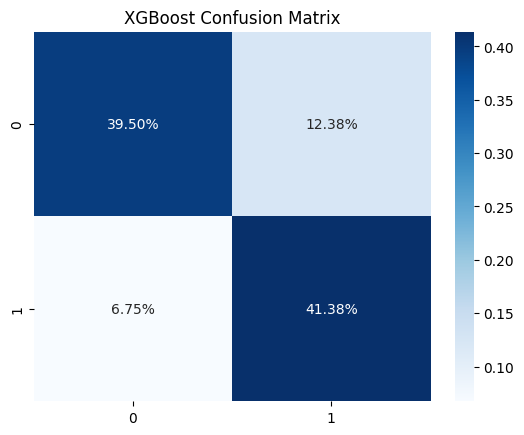

In [111]:
XGB2_cm = confusion_matrix(y_test, XGB2_pred)
sns.heatmap(XGB2_cm/np.sum(XGB2_cm), annot = True, fmt = '0.2%', cmap = 'Blues')
plt.title("XGBoost Confusion Matrix")

#Comparing Models -- Second Iteration:

In [112]:
models2 = pd.DataFrame({
    'Model':['Logistic Regression', 'KNN Regression', 'Decision Tree', 'Random Forest', 'Support Vector', 'XGBoost'],
    'Accuracy' :[LogReg2_acc, KNN2_acc, DecTree2_acc, RFTree2_acc, SVM2_acc, XGB2_acc],
    'Precision' :[LogReg2_precision, KNN2_precision, DecTree2_precision, RFTree2_precision, SVM2_precision, XGB2_precision],
    'Recall' :[LogReg2_recall, KNN2_recall, DecTree2_recall, RFTree2_recall, SVM2_recall, XGB2_recall],
    'F1 Score' :[LogReg2_f1, KNN2_f1, DecTree2_f1, RFTree2_f1, SVM2_f1, XGB2_f1]
})
models2 = models2.sort_values(by='Accuracy', ascending=False)

In [113]:
models2

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.83750,0.826087,0.838961,0.832474
4,Support Vector,0.82375,0.844633,0.776623,0.809202
5,XGBoost,0.80875,0.769767,0.859740,0.812270
2,Decision Tree,0.77375,0.721739,0.862338,0.785799
1,KNN Regression,0.76875,0.731481,0.820779,0.773562
0,Logistic Regression,0.53875,0.518433,0.584416,0.549451


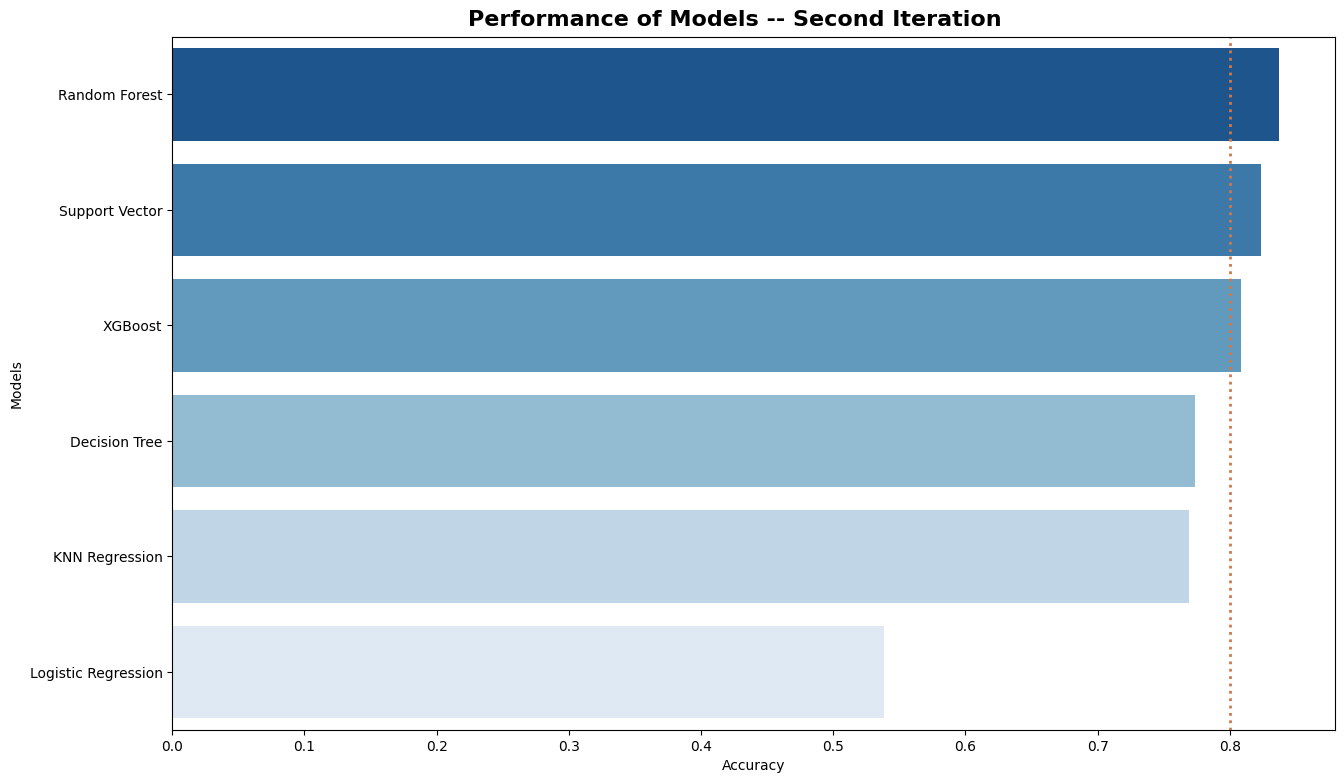

In [114]:
fig = plt.figure(figsize=(15,9))

ax = sns.barplot(data=models2, 
                 y='Model', 
                 x='Accuracy',
                 palette = 'Blues_r')

ax.figure.suptitle('Performance of Models -- Second Iteration',y=0.91, size = 16, color = 'black', weight='bold');

plt.xlabel('Accuracy')
plt.ylabel('Models')
plt.axvline(x = 0.8, ymin = 0, ymax = 1,
            linewidth = 2, linestyle =":",
            color ='#cf7849');

#Comparing First and Second Iterations:

In [115]:
comp_iterations = pd.DataFrame({
    'Model':['Logistic Regression', 'KNN Regression', 'Decision Tree', 'Random Forest', 'Support Vector', 'XGBoost'],
    '2nd Iteration' :[LogReg2_acc, KNN2_acc, DecTree2_acc, RFTree2_acc, SVM2_acc, XGB2_acc],
    '1st Iteration' :[LogReg_acc, KNN_acc, DecTree_acc, RFTree_acc, SVM_acc, XGB_acc],
})
comp_iterations

,Model,2nd Iteration,1st Iteration
0,Logistic Regression,0.53875,0.54000
1,KNN Regression,0.76875,0.66375
2,Decision Tree,0.77375,0.76625
3,Random Forest,0.83750,0.84125
4,Support Vector,0.82375,0.65750
5,XGBoost,0.80875,0.78750


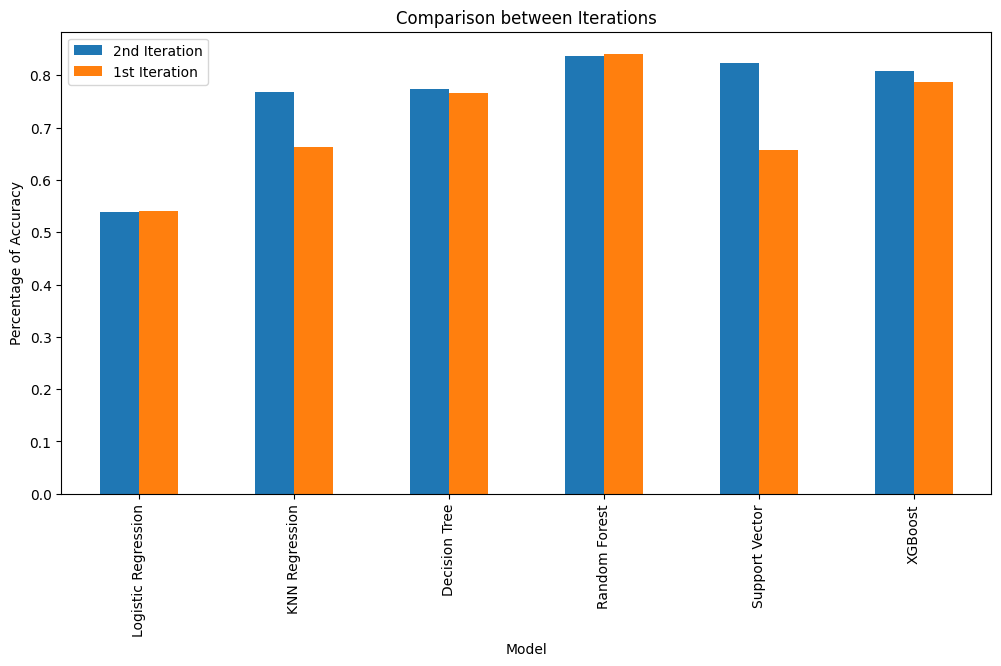

In [116]:
comp_iterations.plot.bar(figsize=(12,6))
plt.xticks([0,1,2,3,4,5],['Logistic Regression', 'KNN Regression', 'Decision Tree', 'Random Forest', 'Support Vector', 'XGBoost'])
plt.ylabel('Percentage of Accuracy') 
plt.xlabel('Model') 
plt.title('Comparison between Iterations');

After our second iteration of model (with hypertuning) we can see that Random Forest Classifier algortihm performed the best with the highest accuracy. We will use Random Forest and SVM to continue our model evaluation with cross validation

#Cross Validation

In [117]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from statistics import mean, stdev

cv = KFold(n_splits=10, random_state=1, shuffle=True)

RFTree2_scores = cross_val_score(RFTree2, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
SVM2_scores = cross_val_score(SVM2, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
XGB2_scores = cross_val_score(XGB2, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

print('Accuracy of CV - Random Forest: %.4f (%.4f)' % (mean(RFTree2_scores), stdev(RFTree2_scores)))
print('Accuracy of CV - SVM: %.4f (%.4f)' % (mean(SVM2_scores), stdev(SVM2_scores)))
print('Accuracy of CV - XGBoost: %.4f (%.4f)' % (mean(XGB2_scores), stdev(XGB2_scores)))

Accuracy of CV - Random Forest: 0.8551 (0.0151)
Accuracy of CV - SVM: 0.8794 (0.0119)
Accuracy of CV - XGBoost: 0.8156 (0.0140)


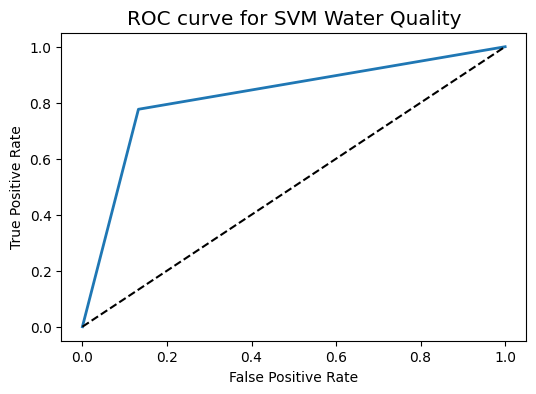

In [118]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, SVM2_pred)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--' )
plt.rcParams['font.size'] = 12
plt.title('ROC curve for SVM Water Quality')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [119]:
from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, SVM2_pred)
print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.8220


In [120]:
Cross_validated_ROC_AUC = cross_val_score(SVM2, X_train, y_train, cv=10, scoring='roc_auc').mean()

print('Cross validated ROC AUC : {:.4f}'.format(Cross_validated_ROC_AUC))

Cross validated ROC AUC : 0.8844
